# WaveNet

In [1]:
import numpy as np
import pywt
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import datasets, transforms
from sktime.datasets import load_from_tsfile_to_dataframe
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tqdm import tqdm
import torch.nn.functional as F
import torch.nn as nn
from torch.optim.lr_scheduler import StepLR
import pandas as pd
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import json
import os
import copy
os.environ["WANDB_API_KEY"] = "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"
import wandb


In [2]:
def get_vit_binary_model():
    weights = models.ViT_B_16_Weights.DEFAULT
    model = models.vit_b_16(weights=weights)

    # 1. Freeze everything
    for param in model.parameters():
        param.requires_grad = False

    # 2. Unlock the last encoder block
    for param in model.encoder.layers[-1].parameters():
        param.requires_grad = True

    # 3. Replace and unlock the classification head
    # ViT_B_16 head input features = 768
    num_ftrs = model.heads.head.in_features
    model.heads = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(num_ftrs, 1),
        nn.Sigmoid()
    )

    for param in model.heads.parameters():
        param.requires_grad = True

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"ViT_B_16 initialized. ONLY encoder.layers[-1] + heads unlocked.")
    print(f"Total trainable parameters: {trainable_params:,}")

    return model

In [3]:
batch_size = 16
model_type = 'ViT_B_16'
lr = 1e-4
weight_decay = 1e-4
patience = 20
epochs = 100
step_size = 8
gamma = 0.3
wavelet = 'morl'
norm_type = 'none'
label_smoothing = 0.1

current_run_name = "wavenet-vit_b_16-v1"
current_notes = '''
ViT_B_16 with ImageNet pre-trained weights. 
Only encoder.layers[-1] + classification head unlocked.
'''

In [4]:
def model_fit_vit(train_loader, test_loader, device,
                  project_name="wavenet-project", run_name=None, notes=None):

    config = {
        "batch_size": batch_size,
        "model_type": model_type,
        "lr": lr,
        "weight_decay": weight_decay,
        "patience": patience,
        "epochs": epochs,
        "step_size": step_size,
        "gamma": gamma,
        "wavelet": wavelet,
        "norm_type": norm_type,
        "label_smoothing": label_smoothing
    }

    wandb.init(
        project=project_name,
        name=run_name,
        notes=notes,
        config=config
    )

    model = get_vit_binary_model().to(device)

    criterion = nn.BCELoss()

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    scheduler = StepLR(optimizer, step_size=config["step_size"], gamma=config["gamma"])

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    early_stop_counter = 0

    for epoch in tqdm(range(config["epochs"]), desc="Training"):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device).float().unsqueeze(1)

            y_smoothed = y * (1 - config["label_smoothing"]) + (config["label_smoothing"] / 2)

            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y_smoothed)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            preds = (outputs > 0.5).float()
            correct_train += (preds == y).sum().item()
            total_train += y.size(0)

        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()

        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train

        log_contents = {
            "epoch": epoch,
            "train/loss": epoch_train_loss,
            "train/accuracy": epoch_train_acc,
            "lr": current_lr
        }

        if test_loader is not None:
            accuracy, recall, precision, f1, auc = evaluate_metrics(model, test_loader, device)

            log_contents.update({
                "test/accuracy": accuracy,
                "test/f1": f1,
                "test/auc": auc
            })

            if accuracy > best_acc:
                best_acc = accuracy
                best_model_wts = copy.deepcopy(model.state_dict())
                wandb.run.summary["best_accuracy"] = best_acc
                early_stop_counter = 0
                print(f"Epoch {epoch}: New best accuracy {best_acc:.4f}")
            else:
                early_stop_counter += 1

        wandb.log(log_contents)

        if early_stop_counter >= config["patience"]:
            print(f"Early stopping at epoch {epoch}.")
            break

    model.load_state_dict(best_model_wts)
    updated_weights = model.state_dict()
    wandb.finish()

    return model, updated_weights

In [5]:
def evaluate_metrics(model, dataloader, device, threshold=0.5):
    """
    Evaluates binary classification metrics for the CWT-based model.
    """
    model.eval()

    y_true_all = []
    y_pred_all = []
    y_proba_all = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            # Binary targets for BCELoss/Scikit-learn
            y_true = y.to(device).float().view(-1)
            
            outputs = model(x)

            # Extract probabilities (since the model ends with Sigmoid)
            probs = outputs.view(-1).float()
            preds = (probs >= threshold).float()

            y_proba_all.append(probs.cpu())
            y_true_all.append(y_true.cpu())
            y_pred_all.append(preds.cpu())

    # Concatenate all batches
    y_test = torch.cat(y_true_all).numpy()
    y_pred = torch.cat(y_pred_all).numpy()
    y_proba = torch.cat(y_proba_all).numpy()

    # Calculate Standard Binary Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    try:
        auc = roc_auc_score(y_test, y_proba)
    except ValueError:
        # Prevents crashing if the batch only contains one class
        auc = float("nan")

    return accuracy, recall, precision, f1, auc

In [6]:
def cwt_transform(signal, wavelet='morl', scales=np.arange(1, 21)):
    signal = np.array(signal)
    coefs, _ = pywt.cwt(signal, scales, wavelet)
    return coefs  # shape: [scale, time]

In [7]:
class CWTTimeSeriesDataset(Dataset):
    def __init__(self, x_df, y_list, wavelet, scales, new_size=(224, 224), norm_type='none'):
        """
        Args:
            norm_type: 'std' for global Mean/Std normalization,
                       'minmax' for global 0-1 scaling,
                       'none' for per-sample normalization (default for jet colormap).
        """
        self.samples = []
        self.labels = []
        self.cmap = cm.get_cmap('jet')

        raw_images = []
        for i in tqdm(range(len(x_df)), desc="Generating Raw CWT"):
            ts = x_df.iloc[i].iloc[0]
            img = cwt_transform(ts, wavelet, scales)
            raw_images.append(img)
            self.labels.append(int(y_list[i]))

        # Global normalization stats (computed before colorization)
        all_data = np.array(raw_images)

        if norm_type == 'std':
            global_mean = np.mean(all_data)
            global_std = np.std(all_data)
            print(f"Global Mean: {global_mean:.4f}, Global Std: {global_std:.4f}")
        elif norm_type == 'minmax':
            global_min = np.min(all_data)
            global_max = np.max(all_data)
            print(f"Global Min: {global_min:.4f}, Global Max: {global_max:.4f}")

        for img in tqdm(raw_images, desc="Jet Colorizing CWT"):
            img_tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0)

            img_resized = F.interpolate(
                img_tensor.unsqueeze(0),
                size=new_size,
                mode='nearest'
            ).squeeze()

            if norm_type == 'std':
                img_norm = (img_resized - global_mean) / (global_std + 1e-8)
                img_norm = (img_norm - img_norm.min()) / (img_norm.max() - img_norm.min() + 1e-8)
            elif norm_type == 'minmax':
                img_norm = (img_resized - global_min) / (global_max - global_min + 1e-8)
            else:
                img_min, img_max = img_resized.min(), img_resized.max()
                img_norm = (img_resized - img_min) / (img_max - img_min + 1e-8)

            img_jet = self.cmap(img_norm.numpy())[:, :, :3]
            img_final = torch.tensor(img_jet, dtype=torch.float32).permute(2, 0, 1)

            self.samples.append(img_final)

    def plot(self, idx):
        img_tensor = self.samples[idx]
        img_np = img_tensor.permute(1, 2, 0).numpy()

        plt.figure(figsize=(6, 6))
        plt.imshow(img_np)
        plt.title(f"Sample {idx} - Jet Colorized")
        plt.axis('off')
        plt.show()

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx], self.labels[idx]

In [8]:
# Plot image
dataset_prefix = "data/data10_IC1_FM_label_wl_20_pw_0_unwo_dropped_1_1_ratio_full_data/TokenItaly_vers0/"
file_path_train = dataset_prefix + "TokenItaly_vers0_TRAIN.ts"
file_path_test = dataset_prefix + "/TokenItaly_vers0_TEST.ts"

x_train, y_train = load_from_tsfile_to_dataframe(file_path_train)
x_test, y_test = load_from_tsfile_to_dataframe(file_path_test)

wavelet = 'morl'
scales = np.arange(1, 21) # 20 scales (height)

train_dataset = CWTTimeSeriesDataset(x_train, y_train, wavelet, scales)
val_dataset = CWTTimeSeriesDataset(x_test, y_test, wavelet, scales)
    


/tmp/ipykernel_154/1994995311.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  self.cmap = cm.get_cmap('jet')
Jet Colorizing CWT: 100%|██████████| 4970/4970 [00:02<00:00, 2167.09it/s]


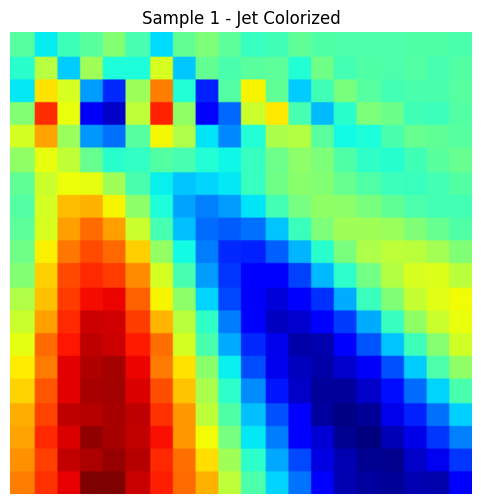

In [9]:
train_dataset.plot(1)

In [9]:
def wl_train_and_test(data_name):

    scales = np.arange(1, 21)

    data_id = data_name[4:6]
    file_path_train = f"data/{data_name}/TokenItaly_vers0/TokenItaly_vers0_TRAIN.ts"
    file_path_test = f"data/{data_name}/TokenItaly_vers0/TokenItaly_vers0_TEST.ts"

    x_train, y_train = load_from_tsfile_to_dataframe(file_path_train)
    x_test, y_test = load_from_tsfile_to_dataframe(file_path_test)

    train_dataset = CWTTimeSeriesDataset(x_train, y_train, wavelet, scales, norm_type=norm_type)
    val_dataset = CWTTimeSeriesDataset(x_test, y_test, wavelet, scales, norm_type=norm_type)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f'Using device: {device} for training on {data_name}')

    model, weights = model_fit_vit(
        train_loader=train_loader,
        test_loader=val_loader,
        device=device,
        project_name="wavenet-project",
        run_name=current_run_name,
        notes=current_notes
    )

    accuracy, recall, precision, f1, auc = evaluate_metrics(model, val_loader, device)

    result_dict = {
        "data_id": data_id,
        "data_name": data_name,
        "model": "ViT_B_16_TransferLearning",
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC score": auc
    }

    return result_dict, weights

In [11]:
# image experimentation

In [ ]:
json_path = 'results.json'
csv_path = 'results.csv'

if os.path.exists(json_path):
    with open(json_path, 'r') as f:
        all_results = json.load(f)
else:
    all_results = []

data_root_path = 'data'

# Define target datasets to run (can be modified)
target_ids = ['10']

all_data_names = sorted([
    name for name in os.listdir(data_root_path)
    if os.path.isdir(os.path.join(data_root_path, name)) and name.startswith('data')
])

# Filter datasets to only include those in target_ids
data_names = []
for name in all_data_names:
    # Check if name matches data{id} or data{id}_...
    for tid in target_ids:
        if name == f"data{tid}" or name.startswith(f"data{tid}_"):
            data_names.append(name)
            break




c = 0
for data_name in data_names:
    result_dict, _ = wl_train_and_test(data_name)
    all_results.append(result_dict)
    c += 1
    print(data_name)

with open(json_path, 'w') as f:
    json.dump(all_results, f, indent=2)


df = pd.DataFrame(all_results)
df.to_csv(csv_path, index=False)

print(f"{c} data is trained and results added to the files...")

/tmp/ipykernel_154/1994995311.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  self.cmap = cm.get_cmap('jet')
Jet Colorizing CWT: 100%|██████████| 4970/4970 [00:02<00:00, 2191.90it/s]


Using device: cuda for training on data10_IC1_FM_label_wl_20_pw_0_unwo_dropped_1_1_ratio_full_data


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: saadsaif0333 (saadsaif0333-sapienza-universit-di-roma). Use `wandb login --relogin` to force relogin


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:17<00:00, 20.1MB/s] 


...

Training:   8%|▊         | 8/100 [08:10<1:34:35, 61.69s/it]

Epoch 7: New best accuracy 0.7296


Training:   9%|▉         | 9/100 [09:12<1:33:41, 61.78s/it]

Epoch 8: New best accuracy 0.7306


Training:  11%|█         | 11/100 [11:17<1:32:12, 62.17s/it]